In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

In [5]:
res=llm.invoke("Hello")
res.content

'Hello! 👋 How can I help you today?'

### State - Global state to pass the data b/a all the nodes

In [6]:
from pydantic import BaseModel

class UserState(BaseModel):
    name: str
    age: int = 0
    email: str

state=UserState(name="Alice", age=30, email="alice@example.com")

In [7]:
state

UserState(name='Alice', age=30, email='alice@example.com')

In [14]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

class MyState(BaseModel):
    message:str=""
    isPassed:bool=False

def greet(state:MyState):
    "I am greet node..."
    print(state.message)
    state.isPassed=True
    state.message="Good Morning!!!"
    return state

graph=StateGraph(MyState)
graph.add_node("welcome",greet)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

final_graph=graph.compile()

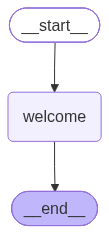

In [15]:
final_graph

In [17]:
res=final_graph.invoke({"message":"Hello,How are you??"})

Hello,How are you??


In [18]:
res

{'message': 'Good Morning!!!', 'isPassed': True}

In [39]:
from random import randint

class ReviewerState(BaseModel):
    score:int=0
    title:str=""
    comments:str=""

def scorer(state:ReviewerState)->ReviewerState:
    state.score=randint(1,10)
    return state

def commenter(state:ReviewerState)->ReviewerState:
    if state.score > 5:
        state.comments = "Well Done!!"
    else:
        state.comments = "Need Improvements."

    return state

graph=StateGraph(ReviewerState)

graph.add_node("score",scorer)
graph.add_node("comment",commenter)

graph.add_edge(START,"score")
graph.add_edge("score","comment")
graph.add_edge("comment",END)

final_graph=graph.compile()

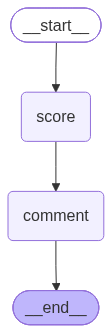

In [36]:
final_graph

In [46]:
res=final_graph.invoke({})

In [47]:
res

{'score': 4, 'title': '', 'comments': 'Need Improvements.'}

### add_messager reducer - for chat history

In [ ]:
from  langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,AIMessage
from typing import Annotated

def custom_reducer(existing:list,new:list):
     all_msg = existing+new
     return all_msg[-1:]

class ChatState(BaseModel):
    message : Annotated[list,custom_reducer]=[]

def chat_bot(state:ChatState):
    state.message = [llm.invoke(state.message)]
    return state

graph=StateGraph(ChatState)

graph.add_node("chat_bot",chat_bot)

graph.add_edge(START,"chat_bot")
graph.add_edge("chat_bot",END)

final_graph=graph.compile()


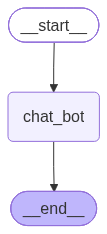

In [68]:
final_graph

In [69]:
res=final_graph.invoke({"message":[HumanMessage(content="Hello!How are you??")]})

In [70]:
print(res)

{'message': [HumanMessage(content='Hello!How are you??', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello! I'm doing great—thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Friendly.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 77, 'total_tokens': 114, 'completion_time': 0.049156366, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.005146145, 'prompt_tokens_details': None, 'queue_time': 0.34322515, 'total_time': 0.054302511}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f6b6-07fc-7441-b302-6295770ffabe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 37, 'total_tokens': 114, 'output_token_details': {'reasoning': 11}})]}


### Routing Langgraph Core Component

In [80]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from typing import Literal

class TicketState(BaseModel):
    issue:str=""
    category:str=""
    response:str=""

def classify(state:TicketState)->TicketState:
    issue=state.issue.lower()
    if "payment" in issue or "amount" in issue:
        state.category = "billing"
    elif "refund" in issue or "cancel" in issue:
        state.category="refund"
    else:
        state.category="status"
    return state

def handel_billing(state:TicketState)->TicketState:
    print("Billing relatd issue.")
    return state

def handel_refund(state:TicketState)->TicketState:
    print("Refund relatd issue.")
    return state

def handel_status(state:TicketState)->TicketState:
    print("Status relatd issue.")
    return state

def router_logic(state:TicketState)->Literal["billing","refund","status"]:
    return state.category

graph=StateGraph(TicketState)
graph.add_node("classify",classify)
graph.add_node("billing",handel_billing)
graph.add_node("refund",handel_refund)
graph.add_node("status",handel_status)

graph.add_edge(START,"classify")
graph.add_conditional_edges("classify",router_logic)
graph.add_edge("billing",END)
graph.add_edge("refund",END)
graph.add_edge("status",END)

final_graph=graph.compile()


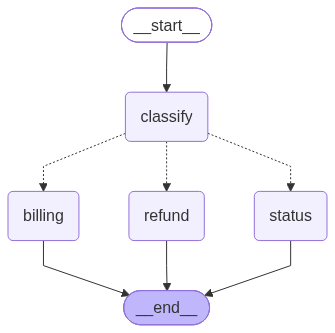

In [81]:
final_graph

In [84]:
response=final_graph.invoke(
    {"issue":"why my payment is stuck??"}
)

Billing relatd issue.


### Memory and checkpointers

In [12]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage


class ChatState(BaseModel):
    messages: Annotated[list, add_messages]
    
def chat_bot(state:ChatState):
    state.messages = [llm.invoke(state.messages)]
    return state

graph = StateGraph(ChatState)

graph.add_node("chat_bot", chat_bot)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)

memory = InMemorySaver()
final_graph = graph.compile(checkpointer=memory)

In [13]:
res = final_graph.invoke(
        {"messages": 
            [ HumanMessage(content="what is his age??") ]
            },
        {"configurable": {"thread_id":"asd1"}}
    )
ans = res["messages"][-1].content
print(ans)

I’m not sure who you’re referring to. Could you let me know which person you mean?


In [14]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

connection = sqlite3.connect("db.sqlite3", check_same_thread=False)
sql_memory = SqliteSaver(connection)
sql_memory.setup()

In [15]:
sqlite_graph = graph.compile(checkpointer=sql_memory)

In [20]:
res = sqlite_graph.invoke(
        {"messages": 
            [ HumanMessage(content="what is his age?") ]
            },
        {"configurable": {"thread_id":"asd1"}}
    )
ans = res["messages"][-1].content
print(ans)

Narendra Modi was born on 17 September 1950, so he is **76 years old** as of today (2 October 2026).


### Agents and Tools

In [33]:
import os
from langchain.tools import tool
import requests

@tool
def weather_tool(city:str):
    """
        Get realtime weather details like temparature,humidity and other information.
        Args:
            city - name for weather details.
        Return - weather data from api response.
    """
    API_URL = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={os.getenv('WEATHER_API_KEY')}"    
    response=requests.get(API_URL)
    if response.status_code==200:
        return response.json()
    
    return "Unable to find details for this city."

@tool
def calculate(expression:str):
    """
    Execute the math expression : Ex. '4+4*4'
    """
    try:
        return eval(expression)
    except:
        return "please provide the correct expression."

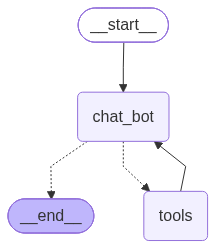

In [34]:
from typing import Annotated
from pydantic import BaseModel
from langchain_core.messages import HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import tools_condition,ToolNode

class AgentState(BaseModel):
    messages:Annotated[list,add_messages]

tools=[weather_tool,calculate]
llm_with_tools=llm.bind_tools(tools)

def chat_bot(state:AgentState):
    res=llm_with_tools.invoke(state.messages)
    state.messages=[res]
    return state

tool_node=ToolNode(tools)

graph=StateGraph(AgentState)

graph.add_node("chat_bot",chat_bot)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_bot")
graph.add_conditional_edges("chat_bot",tools_condition)
graph.add_edge("tools","chat_bot")
graph.add_edge("chat_bot",END)

final_graph=graph.compile(checkpointer=sql_memory)
final_graph

In [36]:
res = final_graph.invoke(
        {"messages": 
            [ HumanMessage(content="what is the ans of 7*8+9??") ]
            },
        {"configurable": {"thread_id":"asd3"}}
    )
ans = res["messages"][-1].content
print(ans)

The result of \(7 \times 8 + 9\) is **65**.


### Human-in-Loop

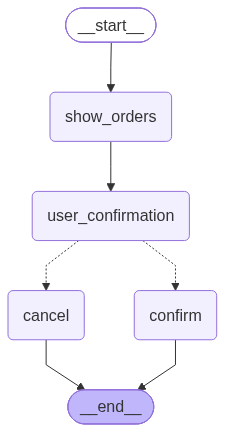

In [45]:
from pydantic import BaseModel
from typing import Literal
from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver

class PurchaseState(BaseModel):
    item:str=""
    price:int=0
    confirmed:bool=False
    status:str=""

def show_order(state:PurchaseState)->PurchaseState:
    print(f"Orders Summary: item:{state.item} & price:{state.price}")
    return state

def user_confirmation(state:PurchaseState)->PurchaseState:
    response=interrupt(
        {
            "question":f"Confirm your purchase for {state.item} and price is {state.price}.Please reply in Yes or No"
        }
    )
    state.confirmed=response.lower()
    return state

def order_cancel(state:PurchaseState)->PurchaseState:
    print("We cancelled your order.Thanks!!!")
    return state

def order_confirm(state:PurchaseState)->PurchaseState:
    print("You successfully placed your order!!!")
    return state

def router(state:PurchaseState)->Literal["cancel","confirm"]:
    if state.confirmed:
        return  "confirm"
    return "cancel"

graph=StateGraph(PurchaseState)

graph.add_node("show_orders",show_order)
graph.add_node("user_confirmation",user_confirmation)
graph.add_node("cancel",order_cancel)
graph.add_node("confirm",order_confirm)

graph.add_edge(START,"show_orders")
graph.add_edge("show_orders","user_confirmation")
graph.add_conditional_edges("user_confirmation",router)
graph.add_edge("cancel",END)
graph.add_edge("confirm",END)

final_graph=graph.compile(checkpointer=InMemorySaver())
final_graph

In [52]:
res = final_graph.invoke(
        {"item": "Samsung S23", "price":22000},
        {"configurable": {"thread_id":"asd10"}}
    )

print(res["__interrupt__"][0].value["question"])


Orders Summary: item:Samsung S23 & price:22000
Confirm your purchase for Samsung S23 and price is 22000.Please reply in Yes or No


In [53]:
#### Confirm the Purchase Order
res = final_graph.invoke(
        Command(resume="yes"),
        {"configurable": {"thread_id":"asd10"}}
    )

You successfully placed your order!!!


In [54]:
res

{'item': 'Samsung S23', 'price': 22000, 'confirmed': True, 'status': ''}

In [5]:
DOCUMENTS = [
    {"id": 1, "text": "LangGraph is a library for building stateful, multi-actor applications with LLMs."},
    {"id": 2, "text": "Python is a high-level programming language known for its simple syntax and readability."},
    {"id": 3, "text": "Machine learning enables systems to learn from data automatically."},
]

### Parallel Operations

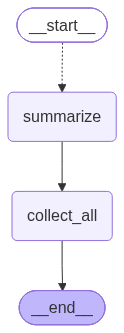

In [3]:
import operator
from datetime import datetime
from typing import Annotated
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Send, Overwrite

def custom_reducer(existing: list, new: list):
    return existing + new

class SummarizerState(BaseModel):
    documents: list[dict] = []
    summaries: Annotated[list, custom_reducer]
    
class Document(BaseModel):
    id: int = 0
    text: str = ""

def route_to_summarizer(state: SummarizerState):
    sends = []
    for doc in state.documents:
        document = Document(id = doc["id"], text=doc["text"])
        sends.append(Send("summarize", document))
        
    return sends


def summarize(state:Document):
    now = datetime.now()
    print("\n Summarize Node...", now.strftime("%M:%S"))
    response = llm.invoke(f"Summarize is 5 Words: {state.text}")
    return {"summaries": [ {"id": state.id, "summary": response.content.strip()} ]}


def collect_all(state:SummarizerState):
    print("All Summaries: ", state.summaries)
    return {}

graph = StateGraph(SummarizerState)
graph.add_node("summarize", summarize)
graph.add_node("collect_all", collect_all)

graph.add_conditional_edges(START, route_to_summarizer, ["summarize"])
graph.add_edge("summarize", "collect_all")
graph.add_edge("collect_all", END)

final_graph = graph.compile(checkpointer=InMemorySaver())
final_graph

In [ ]:
res = final_graph.invoke(
    {"documents": DOCUMENTS, "summaries": Overwrite([])}, 
    {"configurable": {"thread_id":"asd10"}}
)